# EDA: Car Price Prediction

Задача регрессии: предсказание цены продажи автомобиля (`Selling_Price`) по табличным признакам.

## 1. Загрузка данных и знакомство с ними

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.figure_factory as ff
import seaborn as sns


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "dataset.csv").exists():
            return candidate
    raise FileNotFoundError(
        f"(текущая директория: {here})"
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
EDA_DIR = PROJECT_ROOT / "eda"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)

df = pd.read_csv(DATA_DIR / "dataset.csv")
df.head(10)


PROJECT_ROOT: /Users/gleb/Desktop/иис/iis
DATA_DIR: /Users/gleb/Desktop/иис/iis/data


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [2]:
df.info(show_counts=True)
print("\nShape:", df.shape)
print("Duplicates:", df.duplicated().sum())
print("Missing values:\n", df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Shape: (301, 9)
Duplicates: 2
Missing values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [3]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


**Выводы по знакомству с данными:**
- Датасет содержит 301 объект и 9 признаков (числовые и категориальные).
- Целевая переменная: `Selling_Price` (регрессия).
- Числовые признаки: `Year`, `Present_Price`, `Driven_kms`, `Selling_Price`.
- Категориальные признаки: `Car_Name`, `Fuel_Type`, `Selling_type`, `Transmission`, `Owner`.
- Пропусков нет; возможны дубликаты — их удалим на этапе очистки.

## 2. Очистка данных

In [4]:
# Удаляем полные дубликаты
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed duplicates: {before - len(df)}")

# Корректируем типы
df["Fuel_Type"] = df["Fuel_Type"].astype("category")
df["Selling_type"] = df["Selling_type"].astype("category")
df["Transmission"] = df["Transmission"].astype("category")
df["Owner"] = df["Owner"].astype("category")
df["Car_Name"] = df["Car_Name"].astype("category")
df["Year"] = df["Year"].astype("int32")
df["Driven_kms"] = df["Driven_kms"].astype("int32")

# Проверка на невалидные значения
df = df[(df["Selling_Price"] > 0) & (df["Present_Price"] > 0) & (df["Driven_kms"] >= 0)]
df = df.reset_index(drop=True)

df.info(show_counts=True)

Removed duplicates: 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Car_Name       299 non-null    category
 1   Year           299 non-null    int32   
 2   Selling_Price  299 non-null    float64 
 3   Present_Price  299 non-null    float64 
 4   Driven_kms     299 non-null    int32   
 5   Fuel_Type      299 non-null    category
 6   Selling_type   299 non-null    category
 7   Transmission   299 non-null    category
 8   Owner          299 non-null    category
dtypes: category(5), float64(2), int32(2)
memory usage: 11.9 KB


In [5]:
cat_features = df.select_dtypes(include=["category"]).columns.to_list()
num_features = df.select_dtypes(include=["number"]).columns.to_list()
target = "Selling_Price"

print("Categorical:", cat_features)
print("Numeric:", num_features)
print("Target:", target)

for cat in cat_features:
    print(f"{cat} - nunique = {df[cat].nunique()}")

Categorical: ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
Numeric: ['Year', 'Selling_Price', 'Present_Price', 'Driven_kms']
Target: Selling_Price
Car_Name - nunique = 98
Fuel_Type - nunique = 3
Selling_type - nunique = 2
Transmission - nunique = 2
Owner - nunique = 3


## 3. Анализ признаков для модели

In [6]:
# Новый признак: пробег в категориях low / mid / hi
q33, q66 = df["Driven_kms"].quantile([0.33, 0.66])
df["Driven_run"] = df["Driven_kms"].apply(
    lambda x: "low" if x <= q33 else ("hi" if x > q66 else "mid")
).astype("category")
df[["Driven_kms", "Driven_run"]].head()

,Driven_kms,Driven_run
0,27000,mid
1,43000,hi
2,6900,low
3,5200,low
4,42450,hi


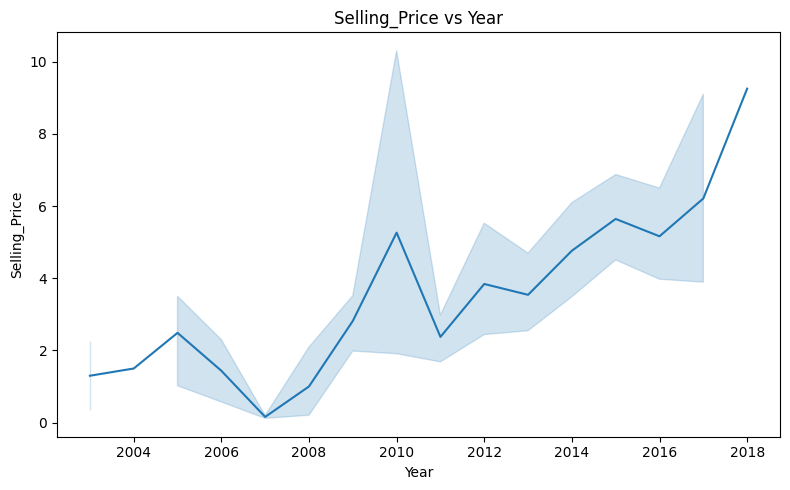

Вывод: более новые автомобили в среднем продаются дороже.


In [7]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x="Year", y="Selling_Price")
plt.title("Selling_Price vs Year")
plt.tight_layout()
plt.savefig(EDA_DIR / "graph1_price_by_year.png", dpi=120)
plt.show()
print("Вывод: более новые автомобили в среднем продаются дороже.")

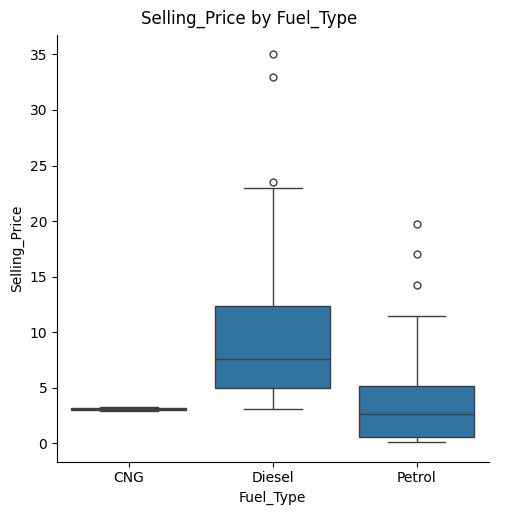

Вывод: Diesel-автомобили в среднем имеют более высокую цену продажи, чем Petrol.


In [8]:
g = sns.catplot(data=df, x="Fuel_Type", y="Selling_Price", kind="box")
g.fig.suptitle("Selling_Price by Fuel_Type", y=1.02)
g.savefig(EDA_DIR / "graph2_price_by_fuel.png", dpi=120)
plt.show()
print("Вывод: Diesel-автомобили в среднем имеют более высокую цену продажи, чем Petrol.")

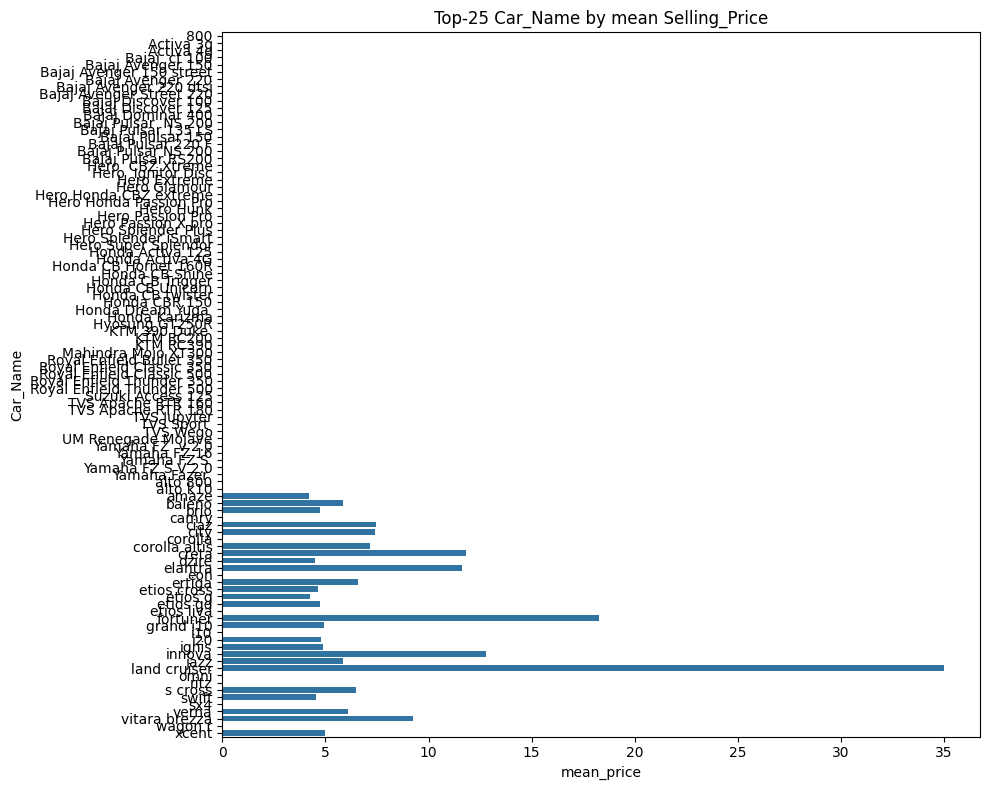

Вывод: модель автомобиля сильно влияет на цену; Car_Name — полезный категориальный признак.


In [9]:
df_car_price = (
    df.groupby("Car_Name", as_index=False, observed=True)
    .agg(mean_price=("Selling_Price", "mean"))
    .sort_values("mean_price", ascending=False)
    .head(25)
)
plt.figure(figsize=(10, 8))
sns.barplot(data=df_car_price, x="mean_price", y="Car_Name")
plt.title("Top-25 Car_Name by mean Selling_Price")
plt.tight_layout()
plt.savefig(EDA_DIR / "graph3_mean_price_by_car.png", dpi=120)
plt.show()
print("Вывод: модель автомобиля сильно влияет на цену; Car_Name — полезный категориальный признак.")

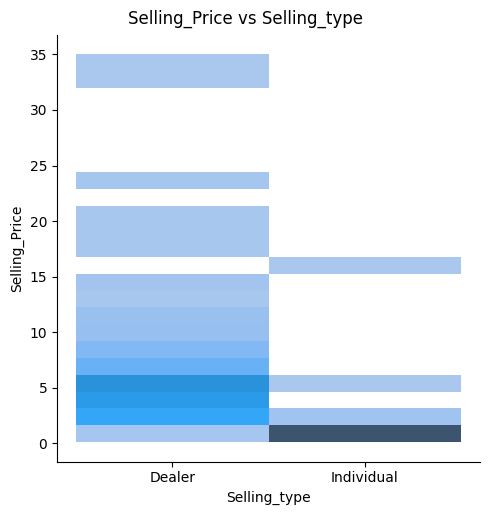

Вывод: у Dealer цены обычно выше, чем у Individual.


In [10]:
g = sns.displot(data=df, x="Selling_type", y="Selling_Price")
g.fig.suptitle("Selling_Price vs Selling_type", y=1.02)
g.savefig(EDA_DIR / "graph4_price_by_selling_type.png", dpi=120)
plt.show()
print("Вывод: у Dealer цены обычно выше, чем у Individual.")

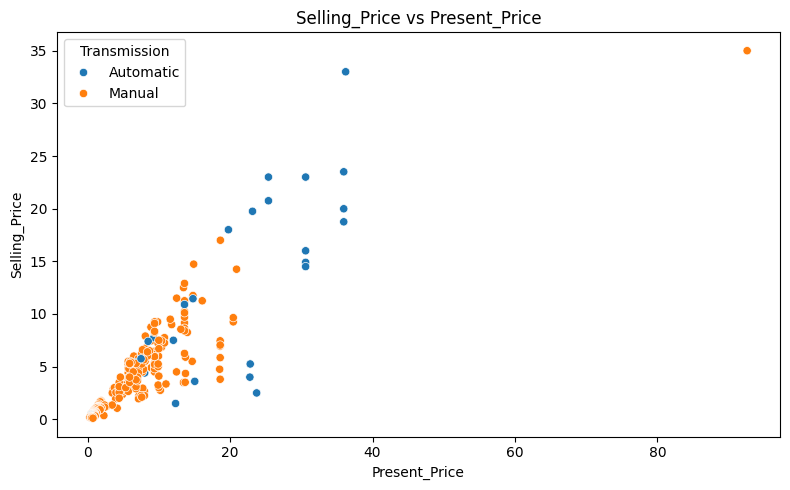

Вывод: Present_Price имеет сильную положительную связь с Selling_Price.


In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price", hue="Transmission")
plt.title("Selling_Price vs Present_Price")
plt.tight_layout()
plt.savefig(EDA_DIR / "graph5_price_vs_present.png", dpi=120)
plt.show()
print("Вывод: Present_Price имеет сильную положительную связь с Selling_Price.")

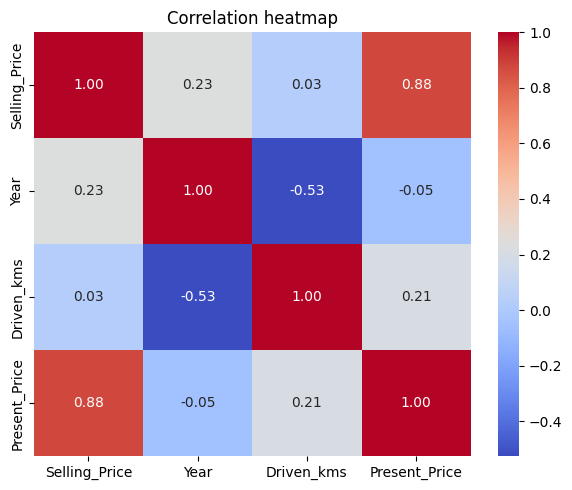

Вывод: сильнейшая корреляция у Present_Price с Selling_Price; Driven_kms связан слабо отрицательно.


In [12]:
# Интерактивный график корреляций
corrs = df[["Selling_Price", "Year", "Driven_kms", "Present_Price"]].corr()
figure = ff.create_annotated_heatmap(
    z=corrs.values,
    x=list(corrs.columns),
    y=list(corrs.index),
    annotation_text=corrs.round(2).values,
    showscale=True,
)
figure.update_layout(title="Interactive correlation heatmap")
figure.write_html(EDA_DIR / "graph6_corr_interactive.html")
# PNG через matplotlib как статичная копия для репозитория
plt.figure(figsize=(6, 5))
sns.heatmap(corrs, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig(EDA_DIR / "graph6_corr.png", dpi=120)
plt.show()
figure.show()
print("Вывод: сильнейшая корреляция у Present_Price с Selling_Price; Driven_kms связан слабо отрицательно.")

## 4. Сохранение финального датасета

In [13]:
clean_path = DATA_DIR / "clean_data.pkl"
df.to_pickle(clean_path)
print("Saved:", clean_path)

df_check = pd.read_pickle(clean_path)
df_check.info()

Saved: /Users/gleb/Desktop/иис/iis/data/clean_data.pkl
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Car_Name       299 non-null    category
 1   Year           299 non-null    int32   
 2   Selling_Price  299 non-null    float64 
 3   Present_Price  299 non-null    float64 
 4   Driven_kms     299 non-null    int32   
 5   Fuel_Type      299 non-null    category
 6   Selling_type   299 non-null    category
 7   Transmission   299 non-null    category
 8   Owner          299 non-null    category
 9   Driven_run     299 non-null    category
dtypes: category(6), float64(2), int32(2)
memory usage: 9.8 KB


## 5. Выводы

### Очистка данных
- Удалены полные дубликаты
- Приведены типы: категориальные (`category`) и целочисленные (`int32`)
- Отфильтрованы невалидные значения цены и пробега
- Пропусков в исходных данных не было

### Новые признаки
- Создан категориальный признак `Driven_run` (low / mid / hi) на основе квантилей пробега

### Закономерности для модели
- `Present_Price` — главный предиктор цены продажи
- Год выпуска положительно связан с ценой
- Diesel и Dealer связаны с более высокой ценой
- `Car_Name` и `Transmission` также влияют на цену
- Пробег влияет слабее, но категориальный `Driven_run` может помочь модели